In [1]:
# %pip install -e .
# %pip install -r requirements.txt
%load_ext autoreload
%autoreload 2

In [2]:
from unittest import result

from ProblemSynchRotations import ProblemSynchRotations
from directsearch import directsearch
from dataprofile import dataprofile
import itertools
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import pandas as pd
import matplotlib.cm as cm

import time
import time
np.random.seed(42)
import pymanopt as po

import sys, os
sys.path.insert(0, os.path.abspath(".."))
# sys.path.insert(0, os.path.abspath("../..")) si le script est 2 niveaux sous la racine
from dimension_influence.problems.ProblemLinearSubspace import ProblemLinearSubspace
from dimension_influence.problems.ProblemEigh import ProblemEigh

# Quick test of the direct-search

In [ ]:


# tester aussi le c, la seed, et 
# sans le warmstart, pas de tableau clair, même l'intrinsèque semble meilleur.
# Problème: le problème n'est pas convexe. Peut-être que la métrique pour les dataprofiles devrait être la norme du gradient

vd = [5]
n = 2
noise = 0 #1e-6 
vseed = [45]
warmstart = 0 #0.2 #0.2 #10000*noise

simplexbudget = 200
projections = [0,1]
psstypes = [1,2,3]
rotations = [1]
euclsimplexs = [1]
gamma = 0.5
Gamma = 2
alpha_0 = 1.0
alpha_max = 1.0
c = 0.01 # si c trop petit, favorable au intrinsèques ?

# c trop petit : projeté meilleur
# warmstart : pas important pour 
# seed
# noise ?


cmapproj = mpl.colormaps["Set1"].colors[1:4]
cmapnoproj = mpl.colormaps["Set1"].colors[1:4]
cmap = [cmapnoproj, cmapproj]
linestyles = ["-", "--"]
linewidths = [2, 1]
variants = ["intrinsic", "projected"]
VF = []
for d in vd:
    plt.figure(figsize=(10, 6))
    plt.show()
    for seed in vseed:
        problem = ProblemSynchRotations(d=d,n=n,noise = noise, seed=seed,warmstart = warmstart)
        point = problem.xstar
        H = problem.H
        H_new = point[0].dot(point[1].T)
        print("DIIIIFFFF",H_new-H)
        for psstype, projection, rotation, euclsimplex in itertools.product(psstypes, projections, rotations, euclsimplexs):
            print(f"Running with psstype={psstype}, projection={projection}, rotation={rotation}, budget={simplexbudget}, simplextype={euclsimplex}")
            result_ds = directsearch(
                    problem,
                    simplexbudget = simplexbudget,
                    projection = projection,
                    psstype = psstype,
                    rotation = rotation,
                    euclsimplex = euclsimplex,
                    gamma = gamma,
                    Gamma = Gamma,
                    alpha_0 = alpha_0,
                    alpha_max = alpha_max,
                    c = c)
            res = result_ds
            vf = res["vf"]
            vx = np.cumsum(res["per_iteration_evaluations"])
            cvg = res["stopcriterion"]
            print(f"Convergence criterion: {cvg}")
            # print(vx)
            plt.plot(
            vx,vf,
            color=cmap[projection][psstype - 1],
            linestyle=linestyles[projection],
            linewidth=linewidths[rotation],
            label=f"PSS{psstype} ({variants[projection]})",
            )
            VF.append(vf[-1])
            print("hey")
    plt.grid()
    plt.title(f"d={d} - budget={simplexbudget}")

    plt.xlabel("Number of evaluations")
    plt.legend()
    print(VF)

In [ ]:
import os
import pickle
path_frame = "experiments/2026-04-28_2rotations_k5_v1/results/results_2026-04-28_14-47-27.pkl"
with open(path_frame, "rb") as f:
    df = pickle.load(f)

# display(results["result"].iloc[0])
# display(df)
display(df.columns)
df = df.drop(['idpb', 'alpha_0', 'gamma', 'Gamma','alpha_max','idalgo'], axis=1)

display(df.columns)


# TODO: compute riemannian and euclidean duration

# display(df["rb_valpha"].iloc[0])
display(df["simplexbudget"].unique())


# Now creating the data profile

a  = len(df["seed"].unique())
c = df.copy()
print(c.columns)

df['rb_lastf'] = df['rb_vf'].transform(lambda x: x[-1] if len(x) > 0 else None)
display(df["rb_vf"])
display(df["psstype"].unique())




# Old format plot

In [118]:
from unittest import result

from ProblemSynchRotations import ProblemSynchRotations
from directsearch import directsearch
from dataprofile import dataprofile
import itertools
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

import os
import pickle
import pandas as pd

os.getcwd()

plt.rcParams.update(
    {
        "font.family": "serif",
        "font.serif": ["cm"],
        "text.usetex": True,
        # 'font.size' : 10,
        # "axes.labelsize": 10,
        # "legend.fontsize": 8,
        # "xtick.labelsize": 8,
        # "ytick.labelsize": 8,
        "figure.figsize": (6.4, 4.0),
        # "pgf.texsystem": "pdflatex",
    }
)
os.listdir("experiments")



['2026-05-03_k5_n2_budg100_noise1em6_warmstart_v1',
 '2026-05-03_k5_n2_budg100_noise1em6_nowarmstart_v1',
 '2026-05-03_k5_n3_budg100_noise1em6_nowarmstart_v1',
 '2026-04-28_2rotations_k5_v1',
 '2026-04-29_2rotations_k5_warmstart_v1']

In [ ]:
path_frame = os.path.join("experiments",'2026-04-29_2rotations_k5_warmstart_v1', "results")
path_frame = os.path.join("experiments",'2026-04-28_2rotations_k5_v1', "results")



last_path = sorted([f for f in os.listdir(path_frame) if f.endswith('.pkl')])[-1]
path_frame = os.path.join(path_frame, last_path)

In [ ]:

with open(path_frame, "rb") as f:
    df = pickle.load(f)

df = df.drop(["idpb", "alpha_0", "gamma", "Gamma", "alpha_max", "idalgo"], axis=1)


# plot formatting 
cmapproj = mpl.colormaps["Set1"].colors[1:4]
cmapnoproj = mpl.colormaps["Set1"].colors[1:4]
cmap = [cmapnoproj, cmapproj]
linestyles = ["-", "--"]
linewidths = [2,2]
variants = ["intrinsic", "projected"]




titlefonts = 28

vtaus = [0.01,0.05,0.1]

fig, ax = plt.subplots(2, 3, figsize=(15, 8))
for i,tau in enumerate(vtaus):
    dp,scalingdim,df_aug = dataprofile(df, tau=tau, euclideansimplex=0, lbdfoeuclideansimplex=0)

    
    for rotation in [0,1]:
        
        # plotting dps
        for projection, psstype in itertools.product([0, 1],  [1, 2, 3]):
            thedp = dp[
                (dp["projection"] == projection)
                & (dp["rotation"] == rotation)
                & (dp["psstype"] == psstype)
            ]
            # display(thedp)
            vx = thedp["alpha"].values*scalingdim
            vf = thedp["ratio_solved"].values
            # if psstype == 1 and projection == 1:
            #     print(vf)
            ax[rotation,i].plot(
            vx,vf,
            color=cmap[projection][psstype - 1],
            linestyle=linestyles[projection],
            linewidth=linewidths[rotation],
            label=f"PSS{psstype} ({variants[projection]})",
            )

        ax[rotation,i].grid()
        # ax[rotation,i].title(f"d={d} - budget={simplexbudget}")
        # ax[rotation,i].xlim(0,5)
        # ax[rotation,i].set_xlabel("Number of simplex gradient evaluations")
        ax[rotation,i].set_title(f"tau: {tau}") if rotation == 1 else None
        # ax[rotation,i].legend()
fig.supxlabel("Number of simplex gradient evaluations", fontsize=titlefonts)
fig.supylabel("Ratio of problems solved", fontsize=titlefonts)
fig.subplots_adjust(wspace=0.2, hspace=0.3)
plt.tight_layout()
fig.savefig("render_results.pdf")

# Plot function values 

In [ ]:
seed = 81

# plotting trajectories for one instance

for projection, rotation, psstype in itertools.product([0, 1], [1], [1, 2, 3]):
    thedf = df[
        (df["projection"] == projection)
        & (df["rotation"] == rotation)
        & (df["psstype"] == psstype)
        & (df["seed"] == seed)
    ]
    vx = thedf["rb_per_iteration_evaluations"].to_list()[0]
    vx = np.array(vx).cumsum()
    vf = thedf["rb_vf"].to_list()[0]
    vf = np.array(vf)
    # print(vf)
    print(vf[-1])

    plt.plot(
    vx,vf,
    color=cmap[projection][psstype - 1],
    linestyle=linestyles[projection],
    linewidth=linewidths[rotation],
    label=f"PSS{psstype} ({variants[projection]})",
    )

# plt.xlim(0,1000)n

# Computational time PSSs

In [ ]:
## Synchronization of rotations

In [4]:
def time_compute(problemtype,mdims,adim, pss_instances = np.arange(1,11), psstypes = [1,2,3], projections = [0,1], rotations = [0,1], pb_instances = np.arange(1,10), printing = False,seed = 42
):
    """vn: rpz taille espace ambiant pour linear subspace et eigh, nombre de rotations pour synchrot
    vd : rpz dimension espace pour linear subspace et eigh, taille des matrices pour synchrot"""
    time_dic = []
    # for mdim, codim in itertools.product(mdims,codims): si je veux libérer codim de mdim
    for mdim in mdims:
        codim = adim - mdim
        print(f"Running for mdim={mdim}, codim={codim}") if printing else None
        adim = mdim + codim
        if problemtype == "eigh":
            problem = ProblemEigh(adim = adim,mdim = mdim)
        elif problemtype == "linearsubspace":
            B = po.manifolds.Stiefel(adim,mdim).random_point()
            problem = ProblemLinearSubspace(B)
        for pb_instance in pb_instances:
            np.random.seed(seed)
            x = problem.manifold.random_point()
            for rotation, projection, psstype, pss_instance in itertools.product(rotations, projections, psstypes, pss_instances):
                # print(f"Rotation: {rotation}, Projection: {projection}, PSS type: {psstype},pss instance: {pss_instance}, d: {mdim}, pb instance: {pb_instance}")
                s = time.process_time()
                problem.build_pss(x,projection=projection, rotation=rotation, psstype=psstype)
                e = time.process_time()
                time_dic.append({
                    "problemtype": problemtype,
                    "mdim": mdim,
                    "codim": codim,
                    "pb_instance": pb_instance,
                    "rotation": rotation,
                    "projection": projection,
                    "psstype": psstype,
                    "pss_instance": pss_instance,
                    "time": e-s
                })
    return time_dic



In [5]:
from tkinter import font

plt.rcParams.update(
    {
        "font.family": "serif",
        "font.serif": ["cm"],
        "text.usetex": True,
        # 'font.size' : 10,
        # "axes.labelsize": 10,
        # "legend.fontsize": 8,
        # "xtick.labelsize": 8,
        # "ytick.labelsize": 8,
        "figure.figsize": (6.4, 4.0),
        # "pgf.texsystem": "pdflatex",
    }
)

def plot_time_results(a, rot=0, adim=40):
    titlefonts = 28

    df = pd.DataFrame(a)

    # Average over all mdims for each combination of psstype, rotation, projection
    results = (
        df.groupby(["psstype", "rotation", "projection"])["time"]
        .agg(avgtime="mean", stdtime="std")
        .reset_index()
        .to_dict(orient="records")
    )

    keys = ["psstype", "rotation", "projection"]
    combos = df[(df["rotation"] == rot)][keys].drop_duplicates().to_dict(orient="records")
    types = sorted(df["psstype"].unique())
    linestyles = {0: "-", 1: ":"}

    fig, ax = plt.subplots()


    cmapproj = mpl.colormaps["Set1"].colors[1:4]
    cmapnoproj = mpl.colormaps["Set1"].colors[1:4]
    cmap = [cmapnoproj, cmapproj]
    linestyles = ["-", "--"]
    titlefonts = 28



    for combo in combos:
        mask = pd.Series([True] * len(df))
        for k, v in combo.items():
            mask &= df[k] == v
        mask &= (df["codim"] + df["mdim"]) == adim
        sub = df[mask].groupby("mdim")["time"].agg(avgtime="mean", stdtime="std").reset_index()
        ax.plot(
        sub["mdim"], sub["avgtime"],
        color=cmap[combo["projection"]][combo["psstype"] - 1],
        marker = ".",
        linestyle=linestyles[combo["projection"]],
        label=f"PSS{combo['psstype']} {['no proj.','proj.'][combo['projection']]}",
        )

        ax.fill_between(
            sub["mdim"],
            sub["avgtime"] - sub["stdtime"],
            sub["avgtime"] + sub["stdtime"],
            color=cmap[combo["projection"]][combo["psstype"] - 1], alpha=0.15
        )

    ax.set_yscale("log")

    from matplotlib.lines import Line2D
    ax.legend()
    ax.set_xlabel("manifold dimension $m$")
    ax.set_ylabel("CPU times (s)")
    # ax.set_title("Build PSS time vs mdim (rotation=0)")
    plt.tight_layout()
    plt.grid(True)
    plt.show()

    return results  # <-- stored here





# fig.supxlabel("Number of simplex gradient evaluations", fontsize=titlefonts)
# fig.supylabel("Ratio of problems solved", fontsize=titlefonts)
# fig.subplots_adjust(wspace=0.2, hspace=0.3)
# plt.tight_layout()
# fig.savefig("render_results.pdf")




# ax[rotation,i].grid()
# # ax[rotation,i].title(f"d={d} - budget={simplexbudget}")
# # ax[rotation,i].xlim(0,5)
# # ax[rotation,i].set_xlabel("Number of simplex gradient evaluations")
# ax[rotation,i].set_title(f"tau: {tau}") if rotation == 1 else None



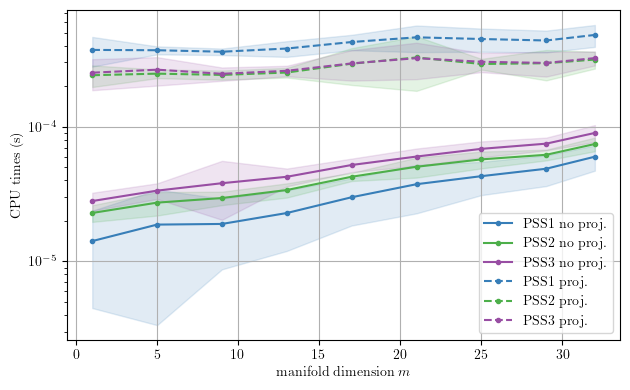

In [17]:
adim = 32
mdims = np.arange(1,adim,4)
mdims = np.append(mdims, adim)
seed=42
a = time_compute("linearsubspace", mdims=mdims, adim = adim, pss_instances = np.arange(0,100), pb_instances = np.arange(0,10), psstypes = [1,2,3], projections = [0,1], rotations = [0,1],printing = False, seed = seed)
pl = plot_time_results(a,rot = 1,adim = adim)


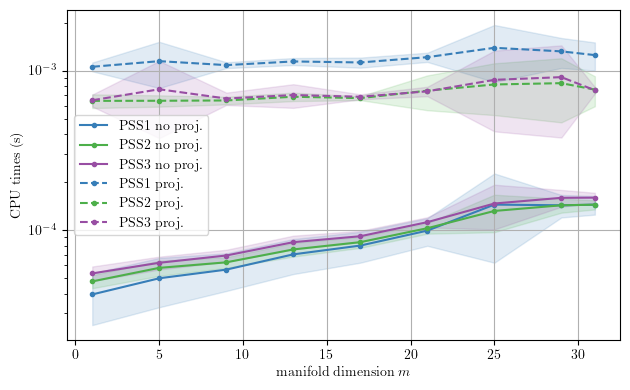

In [19]:
adim = 32
mdims = np.arange(1,adim,4)
mdims = np.append(mdims, adim-1)
a = time_compute("eigh", mdims=mdims, adim = adim, pss_instances = np.arange(0,100), pb_instances = np.arange(0,10), psstypes = [1,2,3], projections = [0,1], rotations = [0,1],printing = False)

pl = plot_time_results(a,rot = 1,adim = adim)

In [9]:
adim = 32
mdims = np.arange(2,adim,4)
mdims = np.append(mdims, adim)
print(mdims)

[ 2  6 10 14 18 22 26 30 32]


In [147]:

a = time_compute("eigh", mdims=np.arange(2,45), vn=[50], pb_instances = np.arange(1,6), psstypes = [1,2,3], projections = [0,1], rotations = [0,1])
plot_time_results(a,rot = 1)


TypeError: time_compute() got an unexpected keyword argument 'vn'